In [2]:
!pip install kagglehub
import kagglehub

# Download latest version of the e-commerce dataset
path = kagglehub.dataset_download("malaiarasugraj/e-commerce-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'e-commerce-dataset' dataset.
Path to dataset files: /kaggle/input/e-commerce-dataset


In [6]:
import pandas as pd
import os

# Find the CSV file inside the downloaded folder
csv_file = os.path.join(path, "diversified_ecommerce_dataset.csv")

# Load it into Python
df = pd.read_csv(csv_file)

# Display the first 5 rows
df.head()

,Product ID,Product Name,Category,Price,Discount,Tax Rate,Stock Level,Supplier ID,Customer Age Group,Customer Location,Customer Gender,Shipping Cost,Shipping Method,Return Rate,Seasonality,Popularity Index
0,P6879,Jacket,Apparel,53.85,5,15,150,S535,35-44,"New York, USA",Male,23.32,Standard,4.49,Yes,56
1,P5132,Camera,Electronics,761.26,10,15,224,S583,25-34,"London, UK",Female,20.88,Overnight,16.11,No,79
2,P2941,Sneakers,Footwear,1756.76,5,8,468,S118,25-34,"Tokyo, Japan",Non-Binary,16.43,Standard,4.93,No,40
3,P8545,Cookbooks,Books,295.24,10,15,25,S104,18-24,"Paris, France",Female,27.49,Standard,1.31,No,93
4,P4594,Camera,Electronics,832.00,10,12,340,S331,55+,"Tokyo, Japan",Male,45.93,Overnight,4.37,No,56


In [7]:
# This gives us a quick statistical summary of all numerical columns
df.describe()

,Price,Discount,Tax Rate,Stock Level,Shipping Cost,Return Rate,Popularity Index
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1005.120742,12.516955,10.002052,250.028536,24.985224,10.492896,49.970211
std,574.451223,8.539929,3.406026,144.676275,14.431730,5.484849,29.164875
min,10.000000,0.000000,5.000000,0.000000,0.000000,1.000000,0.000000
25%,507.860000,5.000000,8.000000,125.000000,12.490000,5.740000,25.000000
50%,1005.430000,15.000000,10.000000,250.000000,24.970000,10.480000,50.000000
75%,1502.310000,20.000000,12.000000,375.000000,37.470000,15.250000,75.000000
max,2000.000000,25.000000,15.000000,500.000000,50.000000,20.000000,100.000000


In [10]:
# This counts how many missing (null) values are in each column
df.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Price,0
Discount,0
Tax Rate,0
Stock Level,0
Supplier ID,0
Customer Age Group,0
Customer Location,0


In [12]:
# This groups the dataset by Category and finds the number of items and their average price
category_summary = df.groupby('Category').agg(
    Total_Items=('Product ID', 'count'),
    Average_Price=('Price', 'mean')
).reset_index()

print(category_summary)

          Category  Total_Items  Average_Price
0          Apparel       199221    1004.347428
1            Books       200751    1006.561486
2      Electronics       200231    1006.564544
3         Footwear       200089    1003.279185
4  Home Appliances       199708    1004.841389


/tmp/ipykernel_25412/1363959856.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Total_Items', data=category_summary, palette='viridis')


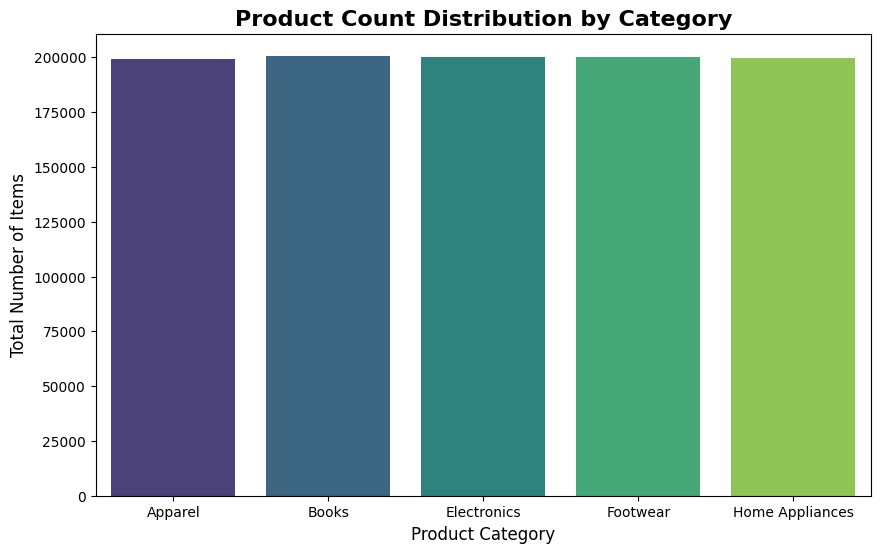

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the size of the chart
plt.figure(figsize=(10, 6))

# Create a bar chart showing total items per category
sns.barplot(x='Category', y='Total_Items', data=category_summary, palette='viridis')

# Add titles and labels so it looks professional
plt.title('Product Count Distribution by Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Number of Items', fontsize=12)

# Display the chart
plt.show()

Correlation between Discount and Popularity: 0.00


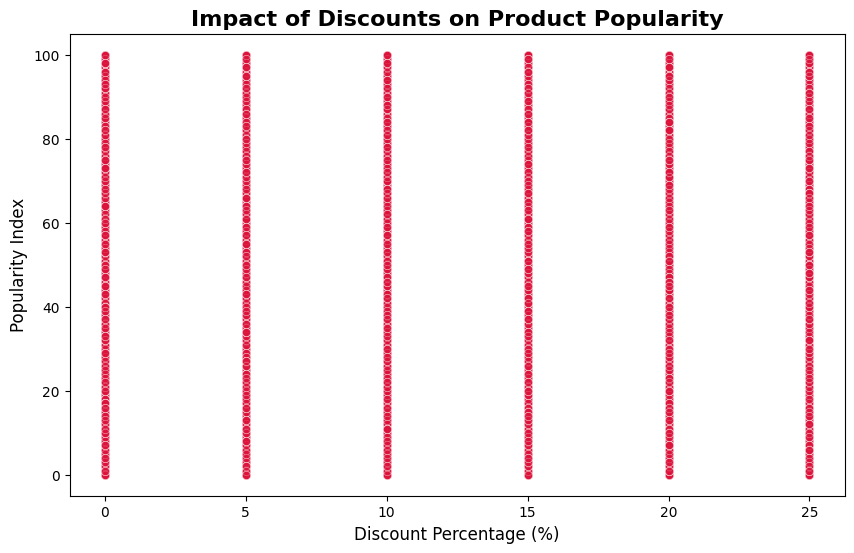

In [16]:
# Check the mathematical correlation between Discount and Popularity
correlation = df['Discount'].corr(df['Popularity Index'])
print(f"Correlation between Discount and Popularity: {correlation:.2f}")

# Plot the trend
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Popularity Index', data=df, alpha=0.5, color='crimson')
plt.title('Impact of Discounts on Product Popularity', fontsize=16, fontweight='bold')
plt.xlabel('Discount Percentage (%)', fontsize=12)
plt.ylabel('Popularity Index', fontsize=12)
plt.show()

In [18]:
# This crosses Location with Shipping Method to find actual variations
shipping_trends = pd.crosstab(df['Customer Location'], df['Shipping Method'])
print(shipping_trends)

Shipping Method          Express  Overnight  Standard
Customer Location                                    
Berlin, Germany            22070      21974     22042
Cape Town, South Africa    22496      22283     22374
Chicago, USA               22278      22284     22302
Dubai, UAE                 22263      22559     22431
Houston, USA               22365      22297     22386
London, UK                 22314      22126     22275
Los Angeles, USA           22078      22323     22106
Mumbai, India              22216      22419     22277
New York, USA              22347      21878     22238
Paris, France              22035      22019     22028
Phoenix, USA               22165      22173     22266
Singapore                  22301      22289     22212
Sydney, Australia          22054      22289     21991
Tokyo, Japan               22206      22118     22294
Toronto, Canada            22087      22243     22229


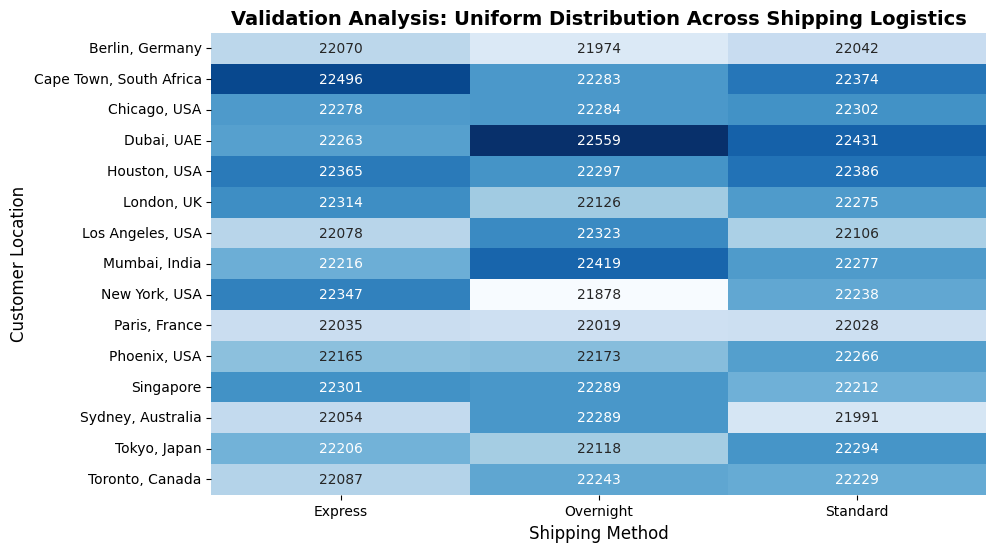

In [19]:
# Plotting the cross-tabulation table as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(shipping_trends, annot=True, fmt='d', cmap='Blues', cbar=False)

# Add professional titles
plt.title('Validation Analysis: Uniform Distribution Across Shipping Logistics', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Method', fontsize=12)
plt.ylabel('Customer Location', fontsize=12)
plt.show()